### Prompt Enginering 
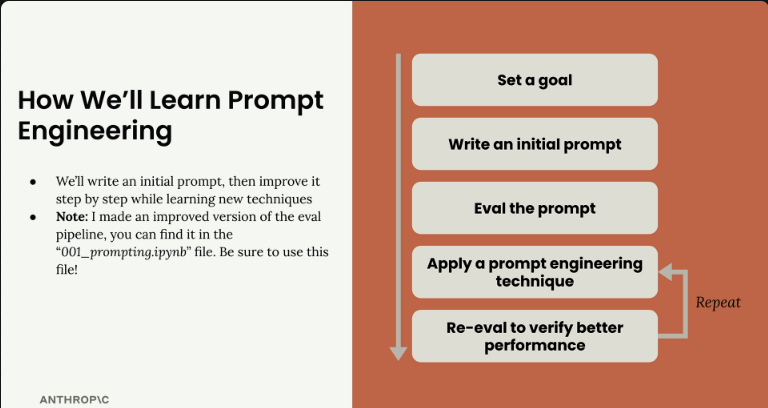

In [1]:
from dotenv import load_dotenv
load_dotenv()

from anthropic import Anthropic

client = Anthropic()

model = "claude-sonnet-4-5"


### Making my first request

message = client.messages.create(
    model=model,
    max_tokens=1000,
    messages=[
        {
            "role": "user",
            "content": "What is quantum computing? Answer in one sentence"
        }
    ]
)

print(message.content[0].text)


### Multi- Turn Conversations 
### Building helper functions

def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)

def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

def chat(messages):
    message = client.messages.create(
        model=model,
        max_tokens=1000,
        messages=messages,
    )
    return message.content[0].text

# putting into practice 

messages = []

add_user_message(messages, "Define quantum computing in one sentence")

answer = chat(messages)

add_assistant_message(messages, answer)

add_user_message(messages, "Write Another Sentence")

final_answer = chat(messages)



### Lesson 5 System prompts
# building a flexible cha fucntion

def chat(messages, system=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
    }


    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

## Now you can call the chat function with or without a system promt:

# Without system prompt
answer = chat(messages)

# With system prompt
system = """
You are a patient math tutor.
Do not directly answer a student's questions.
Guide them to a solution step by step.
"""
answer = chat(messages, system=system)

print(answer)




Quantum computing is a type of computation that harnesses quantum mechanical phenomena like superposition and entanglement to process information in ways that can solve certain problems much faster than classical computers.
Quantum computers use quantum bits (qubits) that can exist in multiple states simultaneously, unlike classical bits that are strictly either 0 or 1.


In [6]:
"""
prompt_evaluator.py

A working equivalent of the PromptEvaluator class used in the Claude Academy
prompt engineering lessons. Matches the lesson's API:

    evaluator = PromptEvaluator(max_concurrent_tasks=3)
    dataset = evaluator.generate_dataset(...)
    results = evaluator.run_evaluation(...)

Uses threads rather than asyncio so it works the same in a notebook or a script.
"""

import html
import json
from concurrent.futures import ThreadPoolExecutor

from anthropic import Anthropic
from dotenv import load_dotenv

load_dotenv()

client = Anthropic()
MODEL = "claude-haiku-4-5-20251001"


# --- helpers -------------------------------------------------------------

def add_user_message(messages, text):
    messages.append({"role": "user", "content": text})


def add_assistant_message(messages, text):
    messages.append({"role": "assistant", "content": text})


def chat(messages, system=None, stop_sequences=None, max_tokens=4000):
    params = {"model": MODEL, "max_tokens": max_tokens, "messages": messages}
    if system:
        params["system"] = system
    if stop_sequences:
        params["stop_sequences"] = stop_sequences

    message = client.messages.create(**params)
    if message.stop_reason == "max_tokens":
        print("WARNING: response truncated - raise max_tokens")
    return message.content[0].text


def _json_chat(prompt):
    """Ask for JSON, using prefill + stop sequence, and parse it."""
    messages = []
    add_user_message(messages, prompt)
    add_assistant_message(messages, "```json")
    text = chat(messages, stop_sequences=["```"])
    return json.loads(text.strip())


# --- the evaluator -------------------------------------------------------

class PromptEvaluator:
    def __init__(self, max_concurrent_tasks=3):
        self.max_concurrent_tasks = max_concurrent_tasks

    def generate_dataset(
        self,
        task_description,
        prompt_inputs_spec,
        output_file=None,
        num_cases=3,
    ):
        spec = "\n".join(f'- "{k}": {v}' for k, v in prompt_inputs_spec.items())
        example = ", ".join(f'"{k}": "..."' for k in prompt_inputs_spec)

        prompt = f"""
Generate an evaluation dataset for this task:

{task_description}

Each test case is a JSON object with these fields:
{spec}

Output a JSON array of {num_cases} objects, varied and realistic.

Example shape:
[
  {{{example}}}
]

Output only the JSON array.
"""
        dataset = _json_chat(prompt)

        if output_file:
            with open(output_file, "w") as f:
                json.dump(dataset, f, indent=2)
            print(f"Saved {len(dataset)} cases to {output_file}")

        return dataset

    def grade(self, prompt_inputs, output, extra_criteria=None):
        criteria = f"\nAdditional criteria:\n{extra_criteria}\n" if extra_criteria else ""

        prompt = f"""
You are an expert evaluator. Grade this AI-generated output.

Inputs given to the prompt:
{json.dumps(prompt_inputs, indent=2)}

Output produced:
{output}
{criteria}
Respond with a JSON object containing:
- "strengths": array of 1-3 key strengths
- "weaknesses": array of 1-3 key areas for improvement
- "reasoning": concise explanation of your assessment
- "score": number from 1 to 10

Be strict. Reserve 9-10 for output that fully meets every criterion.
"""
        return _json_chat(prompt)

    def run_evaluation(
        self,
        run_prompt_function,
        dataset_file=None,
        dataset=None,
        extra_criteria=None,
        json_output_file="results.json",
        html_output_file="report.html",
    ):
        if dataset is None:
            with open(dataset_file) as f:
                dataset = json.load(f)

        def run_one(case):
            try:
                output = run_prompt_function(case)
                grade = self.grade(case, output, extra_criteria)
                return {
                    "inputs": case,
                    "output": output,
                    "score": grade["score"],
                    "strengths": grade.get("strengths", []),
                    "weaknesses": grade.get("weaknesses", []),
                    "reasoning": grade.get("reasoning", ""),
                }
            except Exception as e:
                return {
                    "inputs": case,
                    "output": "",
                    "score": 0,
                    "strengths": [],
                    "weaknesses": [f"Evaluation failed: {e}"],
                    "reasoning": str(e),
                }

        with ThreadPoolExecutor(max_workers=self.max_concurrent_tasks) as pool:
            results = list(pool.map(run_one, dataset))

        scores = [r["score"] for r in results]
        average = sum(scores) / len(scores) if scores else 0

        for r in results:
            first_key = next(iter(r["inputs"]), None)
            label = str(r["inputs"].get(first_key, ""))[:50] if first_key else ""
            print(f"{r['score']:>4}/10  {label}")
        print(f"\nAverage: {average:.2f} over {len(results)} cases")

        if json_output_file:
            with open(json_output_file, "w") as f:
                json.dump({"average": average, "results": results}, f, indent=2)

        if html_output_file:
            self._write_html(results, average, html_output_file)
            print(f"Report: {html_output_file}")

        return {"average": average, "results": results}

    @staticmethod
    def _write_html(results, average, path):
        def esc(x):
            return html.escape(str(x))

        cards = []
        for i, r in enumerate(results, 1):
            strengths = "".join(f"<li>{esc(s)}</li>" for s in r["strengths"])
            weaknesses = "".join(f"<li>{esc(w)}</li>" for w in r["weaknesses"])
            cards.append(f"""
            <section>
              <h2>Case {i} &mdash; {r['score']}/10</h2>
              <h3>Inputs</h3>
              <pre>{esc(json.dumps(r['inputs'], indent=2))}</pre>
              <h3>Output</h3>
              <pre>{esc(r['output'])}</pre>
              <h3>Strengths</h3><ul>{strengths}</ul>
              <h3>Weaknesses</h3><ul>{weaknesses}</ul>
              <h3>Reasoning</h3><p>{esc(r['reasoning'])}</p>
            </section>""")

        doc = f"""<!doctype html>
<html><head><meta charset="utf-8"><title>Evaluation report</title>
<style>
  body {{ font-family: system-ui, sans-serif; max-width: 55rem; margin: 2rem auto;
         padding: 0 1rem; line-height: 1.5; }}
  section {{ border: 1px solid #ddd; border-radius: 8px; padding: 1rem 1.25rem;
             margin-bottom: 1.5rem; }}
  pre {{ background: #f6f6f6; padding: .75rem; border-radius: 6px;
         overflow-x: auto; white-space: pre-wrap; }}
  h1 {{ margin-bottom: .25rem; }}
</style></head>
<body>
<h1>Evaluation report</h1>
<p><strong>Average score: {average:.2f}/10</strong> across {len(results)} cases</p>
{''.join(cards)}
</body></html>"""

        with open(path, "w", encoding="utf-8") as f:
            f.write(doc)

In [7]:
from prompt_evaluator import PromptEvaluator, add_user_message, chat

evaluator = PromptEvaluator(max_concurrent_tasks=3)

dataset = evaluator.generate_dataset(
    task_description="Write a compact, concise 1 day meal plan for a single athlete",
    prompt_inputs_spec={
        "height": "Athlete's height in cm",
        "weight": "Athlete's weight in kg",
        "goal": "Goal of the athlete",
        "restrictions": "Dietary restrictions of the athlete",
    },
    output_file="dataset.json",
    num_cases=3,
)

ModuleNotFoundError: No module named 'prompt_evaluator'

In [8]:
from prompt_evaluator import PromptEvaluator, add_user_message, chat

evaluator = PromptEvaluator(max_concurrent_tasks=3)

dataset = evaluator.generate_dataset(
    task_description="Write a compact, concise 1 day meal plan for a single athlete",
    prompt_inputs_spec={
        "height": "Athlete's height in cm",
        "weight": "Athlete's weight in kg",
        "goal": "Goal of the athlete",
        "restrictions": "Dietary restrictions of the athlete",
    },
    output_file="dataset.json",
    num_cases=3,
)

Saved 3 cases to dataset.json


In [9]:
evaluator = PromptEvaluator(max_concurrent_tasks=5)

In [10]:
dataset = evaluator.generate_dataset(
    task_description="Write a compact, concise 1 day meal plan for a single athlete",
    prompt_inputs_spec={
        "height": "Athlete's height in cm",
        "weight": "Athlete's weight in kg", 
        "goal": "Goal of the athlete",
        "restrictions": "Dietary restrictions of the athlete"
    },
    output_file="dataset.json",
    num_cases=3
)

Saved 3 cases to dataset.json


In [11]:
def run_prompt(prompt_inputs):
    prompt = f"""
What should this person eat?

- Height: {prompt_inputs["height"]}
- Weight: {prompt_inputs["weight"]}
- Goal: {prompt_inputs["goal"]}
- Dietary restrictions: {prompt_inputs["restrictions"]}
"""
    
    messages = []
    add_user_message(messages, prompt)
    return chat(messages)

In [12]:
results = evaluator.run_evaluation(
    run_prompt_function=run_prompt,
    dataset_file="dataset.json",
    extra_criteria="""
The output should include:
- Daily caloric total
- Macronutrient breakdown  
- Meals with exact foods, portions, and timing
"""
)

   6/10  180
   4/10  165
   6/10  188

Average: 5.33 over 3 cases
Report: report.html


### Being Clear and Direct

The first line of your prompt is the most important part of your entire request. This is where you set the stage for everything that follows, and getting it right can dramatically improve your results.

### Being Specific 
When working with Claude, one of the most effective ways to improve your results is to be specific about what you want. Instead of leaving everything up to the model's interpretation, you can provide clear guidelines or steps that direct Claude toward the kind of output you're looking for.

Think about it this way: if you ask Claude to "write a short story about a character who discovers a hidden talent," Claude could go in countless directions. The story might be 200 words or 2,000 words. It might have one character or five. It could focus on any type of talent discovery scenario.




This can increase evaluation score.

#### We can use XML tags to give examples clearl < This is a XML>

### Introducing Tool use

Tools allow Claude to access information from the outside world, extending its capabilities beyond what it learned during training. By default, Claude only knows information from its training data and can't access current events, real-time data, or external systems. Tool use solves this limitation by creating a structured way for Claude to request and receive fresh information.